## This cell imports libraries for deep learning 

In [4]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import KerasTensor
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print("Imports successful!")

TensorFlow version: 2.21.0
Imports successful!


## Creating a Binary Classification Dataset

This filters the original dataset to create a new directory containing only the two classes needed for binary classification: healthy and bacterial_blight.

**Source** : cassava_small

**Destination** : cassava_binary

and then it wipes out any old versions of the destination folder and copies over the specific classes we need, ensuring we start with a clean, focused dataset.

In [5]:
import os
import shutil

original_data_dir = "cassava_small"
binary_data_dir = "cassava_binary"

classes_to_keep = ["healthy", "bacterial_blight"]

# remove old binary folder if it exists
if os.path.exists(binary_data_dir):
    shutil.rmtree(binary_data_dir)

os.makedirs(binary_data_dir, exist_ok=True)

for cls in classes_to_keep:
    src = os.path.join(original_data_dir, cls)
    dst = os.path.join(binary_data_dir, cls)
    shutil.copytree(src, dst)

print("Binary dataset created.")
print("Classes:", os.listdir(binary_data_dir))

Binary dataset created.
Classes: ['healthy', 'bacterial_blight']


## checking class Distribution

This step loops through the newly created folders to confirm that the data transfer was successful and to check the balance between our classes.

**Process**: Iterates through each class in the binary directory.

**Output**: Prints the specific number of images found in both the healthy and bacterial_blight folders.

**Action** : Provides a quick headcount so we can spot any data imbalances right away before moving on to training.

In [6]:
for cls in sorted(os.listdir(binary_data_dir)):
    cls_path = os.path.join(binary_data_dir, cls)
    print(f"{cls}: {len(os.listdir(cls_path))} images")

bacterial_blight: 200 images
healthy: 200 images


In [7]:
data_dir = "cassava_binary"

In [8]:
print("binary class", sorted(os.listdir(data_dir)))

binary class ['bacterial_blight', 'healthy']


## Visualizing the Dataset: Random Samples inspection

This block pulls a few random examples from each class to give us a first-hand look at the actual image quality and labeling.

**Process**: Grabs 4 random images per class and organizes them into a clean grid.

**Purpose**: Helps us manually verify that the labels match the images and check for any obvious lighting or quality issues.

**Action**: Generates a quick visual gallery, making it easy to confirm that our input data is ready for the model.


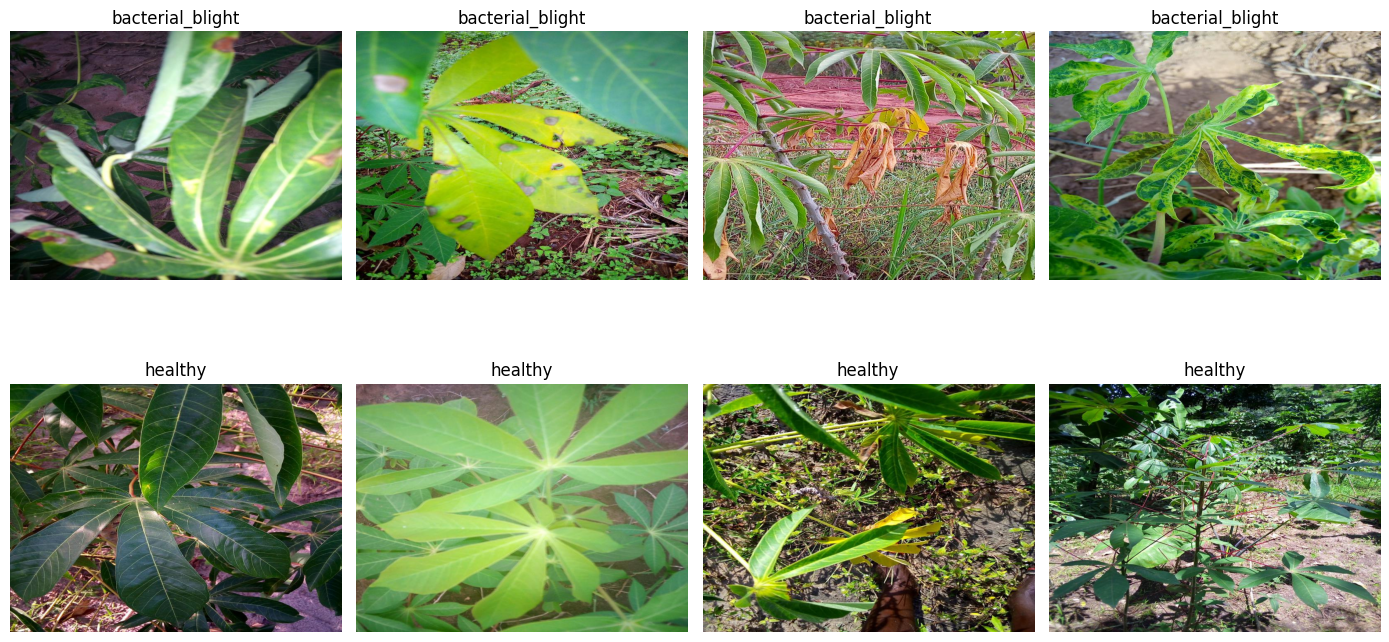

In [9]:
import math

classes = sorted(os.listdir(data_dir))
samples_per_class = 4
total_images = len(classes) * samples_per_class

cols = 4
rows = math.ceil(total_images / cols)

plt.figure(figsize=(14, 4 * rows))

plot_idx = 1
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    images = [
        f for f in os.listdir(cls_path)
        if os.path.isfile(os.path.join(cls_path, f))
    ]

    selected = random.sample(images, min(len(images), samples_per_class))

    for img_name in selected:
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path)

        plt.subplot(rows, cols, plot_idx)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
        plot_idx += 1

plt.tight_layout()
plt.show()

## Data preprocessing: Scaling, Augumentation and Loading 

This step sets up the ImageDataGenerators, which handle the heavy lifting of transforming our raw images into ready-to-train tensors.

**Normalization**: Rescales pixel values to the range, helping the model converge much faster.

**Augmentation**: Applies random transformations (rotation, zoom, flips) to the training set, forcing the model to learn general features rather than specific orientations.

**Splitting**: Automatically carves out of the data for validation to monitor performance on unseen images.
Action: Creates the train_data and val_data generators, effectively turning our folder structure into a stream of processed batches for training.

In [10]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 320 images belonging to 2 classes.
Found 80 images belonging to 2 classes.


## Mapping Labels: Identifying class indices

This simple check confirms how the generator has numerically encoded our text labels, which is essential for interpreting the model's final predictions.

**Process**: Accesses the class_indices dictionary from the training generator.

**Purpose**: Maps folder names (like healthy) to their assigned integers (0 or 1).

**Action**: Provides the "decoder key" we’ll need later to translate the model's numerical output back into human-readable categories.


In [11]:
print("class indices:", train_data.class_indices)

class indices: {'bacterial_blight': 0, 'healthy': 1}


## Model Architecture: Transfer learning with mobileNetV2

This block defines the "brain" of our project. Instead of starting from scratch, we’re using Transfer Learning to leverage a pre-trained model that already knows how to recognize shapes and textures.

**The Base**: Loads MobileNetV2, a lightweight model trained on millions of images (ImageNet), with its top layers removed so we can add our own.

**Freezing**: Sets trainable = False to "freeze" the pre-trained weights, ensuring we don't ruin the existing knowledge while we train our custom layers.

**Custom Head**: Adds a GlobalAveragePooling layer to condense the data, followed by a Dense layer for reasoning and Dropout to prevent the model from over-relying on specific pixels (reducing overfitting).

**Output**: Ends with a 2-unit Softmax layer to give us a clear probability for our two classes: healthy or bacterial_blight.

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)


## Mobile compilation: Defining the strategy
This step sets the "rules" for how the model will learn from its mistakes during the training process.

**Optimizer**: Uses Adam, a popular and efficient algorithm that automatically adjusts the learning rate as the model trains.

**Loss Function**: Employs Categorical Crossentropy, which measures the "distance" between the model's predictions and the actual labels (ideal for multi-class or binary classification with one-hot encoding).

**Metrics**: Tracks Accuracy, giving us a straightforward percentage of how many images the model is correctly identifying in real-time.
Action: Finalizes the model's internal setup, officially preparing it for the training phase.

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Traning Guard: Callbacks for performance and Safety

This block sets up Callbacks—automated tools that monitor the model during training to prevent wasted time and ensure we keep the best possible version.

**Early Stopping**: Watchdogs the val_loss. If the model stops improving for 3 consecutive epochs, it pulls the plug to prevent overfitting and restores the weights from when the model was at its peak.

**Model Checkpoint**: Automatically saves a file named best_cassava_binary_model.keras whenever the model hits a new all-time high in validation accuracy.

**Action**: Acts as an insurance policy, guaranteeing that we don't end up with a "burned out" model at the end of the training process.

In [19]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_cassava_binary_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

## Model Training: The Learning Phase

This is where the magic happens—the model begins iterating through our prepared images, adjusting its weights to learn the difference between healthy and diseased plants.

**Training Loop**: Runs for up to 12 epochs, during which the model processes the entire training dataset over and over.

**Validation**: After every epoch, it tests itself on the validation data to see how well it generalizes to images it hasn't "memorized."

**Callbacks in Action**: Our EarlyStopping and ModelCheckpoint are active here, saving the best version of the model and stopping early if the accuracy plateaus.

**Action**: Stores the entire training journey in the history object, which we can use next to visualize the accuracy and loss curves.

In [20]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=12,
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.5134 - loss: 0.9224
Epoch 1: val_accuracy improved from None to 0.61250, saving model to best_cassava_binary_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 617ms/step - accuracy: 0.5500 - loss: 0.8419 - val_accuracy: 0.6125 - val_loss: 0.8737
Epoch 2/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.6814 - loss: 0.6288
Epoch 2: val_accuracy improved from 0.61250 to 0.62500, saving model to best_cassava_binary_model.keras
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 472ms/step - accuracy: 0.6938 - loss: 0.6278 - val_accuracy: 0.6250 - val_loss: 0.6966
Epoch 3/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.7075 - loss: 0.5896
Epoch 3: val_accuracy did not improve from 0.62500
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 354ms/step - accuracy: 0.7094 - loss: 0.5642 - val_accuracy: 0.5875 - val_loss: 0.6332
Epoch 4/12
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.7637 - loss: 0.5414
Epoch 4: val_accuracy did not improve from 0.6250

**Action**: Loads the top-performing version of the model from the saved checkpoint to ensure we're using the most accurate weights for final predictions.

In [21]:
best_model = best_model = tf.keras.models.load_model("best_cassava_binary_model.keras")

**Action**: Runs the final performance check on the validation set, printing out the exact accuracy and loss the model achieved at its peak.

In [22]:
val_loss, val_accuracy = best_model.evaluate(val_data)
print("Best Validation Loss:", val_loss)
print("Best Validation Accuracy:", val_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - accuracy: 0.6750 - loss: 0.6123
Best Validation Loss: 0.6122841835021973
Best Validation Accuracy: 0.675000011920929


**Action**: Generates a detailed classification report that breaks down precision, recall, and F1-score for each class, giving us a transparent look at how the model handles healthy versus diseased plants.

In [23]:
pred_probs = best_model.predict(val_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = val_data.classes
class_names = list(val_data.class_indices.keys())

print(classification_report(true_classes, pred_classes, target_names=class_names, zero_division=0))

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step
                  precision    recall  f1-score   support

bacterial_blight       0.64      0.80      0.71        40
         healthy       0.73      0.55      0.63        40

        accuracy                           0.68        80
       macro avg       0.69      0.68      0.67        80
    weighted avg       0.69      0.68      0.67        80



### Confusion Matrix Interpretation

The confusion matrix shows how well the model distinguishes between healthy cassava leaves and those affected by bacterial blight.

- The model correctly classified 26 bacterial blight samples and 28 healthy samples.
- However, 14 bacterial blight samples were incorrectly classified as healthy, indicating some difficulty in detecting disease cases.
- Additionally, 12 healthy samples were misclassified as bacterial blight.

This suggests that while the model performs reasonably well overall, it has a tendency to misclassify some diseased leaves as healthy, which could be a concern in real-world usage where missing a disease is more critical than a false alarm.

Overall, the confusion matrix highlights areas where the model can be improved, particularly in reducing false negatives for bacterial blight.

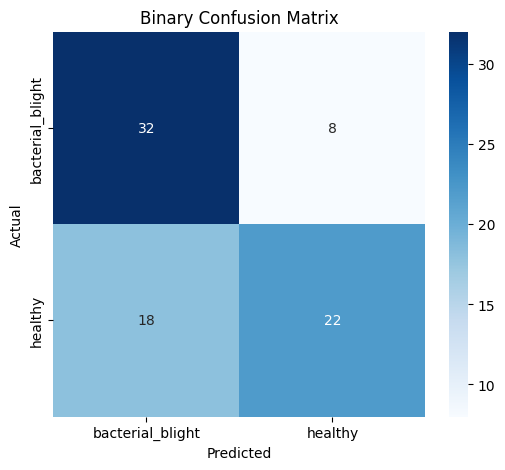

In [24]:
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Binary Confusion Matrix")
plt.show()

**Action**: Performs a final reload and save of our top-performing model under a definitive filename, confirming the model is officially ready for deployment or production.

In [25]:
best_model = tf.keras.models.load_model("best_cassava_binary_model.keras")
best_model.save("best_cassava.final.keras")
print("Model saved successfully")

Model saved successfully


In [26]:
test_image_path = "cassava_small/bacterial_blight/1026467332.jpg" 

**Action**: Runs a real-world test on a single image, processing the pixels to output a prediction of bacterial_blight with 77.72% confidence, visually confirming how the model handles specific, individual samples.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step


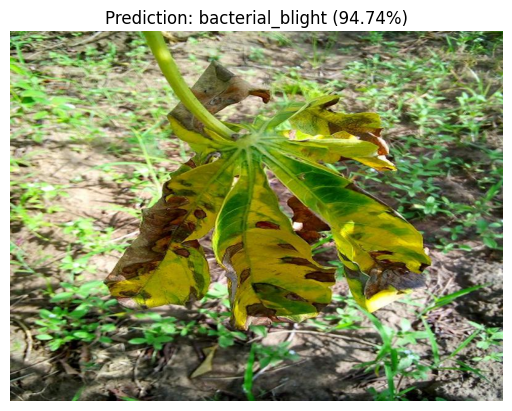

Predicted class: bacterial_blight
Confidence: 0.9474144


In [27]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

img = load_img(test_image_path, target_size=(224, 224))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)

plt.imshow(load_img(test_image_path))
plt.title(f"Prediction: {predicted_class} ({confidence:.2%})")
plt.axis("off")
plt.show()

print("Predicted class:", predicted_class)
print("Confidence:", confidence)

### Training vs Validation Accuracy

This graph shows how the model performed across training epochs. The training accuracy indicates how well the model learned from the training data, while the validation accuracy shows how well it generalized to unseen data. The gap between the two curves helps identify whether the model is learning useful patterns or beginning to overfit.

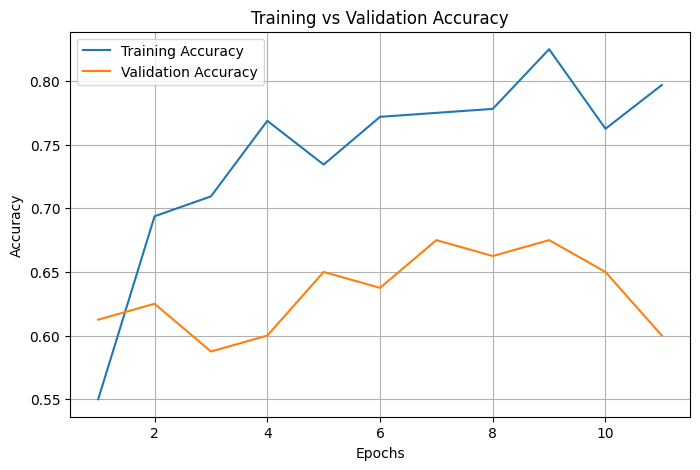

In [28]:
import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Training vs Validation Loss

This graph shows how the model loss changed during training. A decreasing training loss suggests that the model is learning, while the validation loss helps assess how well the model performs on unseen data. If validation loss begins to increase while training loss continues to decrease, it may indicate overfitting.

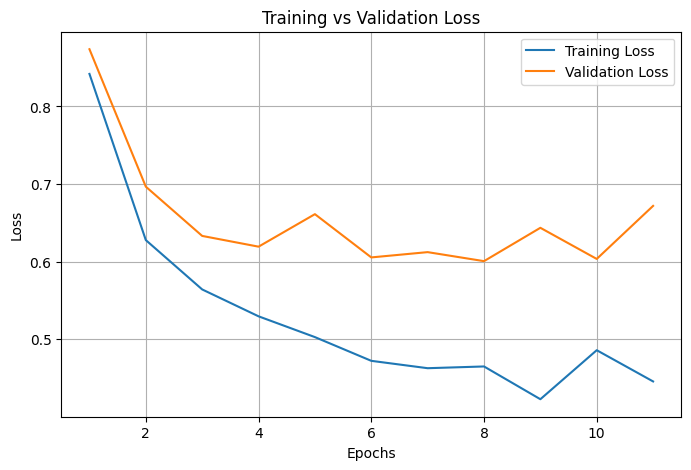

In [29]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()